# Kernel Density Estimation

KDE estimates the density of normal data by placing a Gaussian kernel on each training point. A new point is considered anomalous if its log-likelihood under the model falls below a threshold, set to the 5th percentile of training scores (corresponding to a 5% false positive rate). Bandwidth is fixed at 0.5, a reasonable value for StandardScaler-normalised data.

For each file, the model is trained on the normal segment (`anomaly==0`) and evaluated on the full sequence. The evaluation metric is the **first detection delay**: the number of timesteps between the start of the anomaly and the first alarm raised by the model.

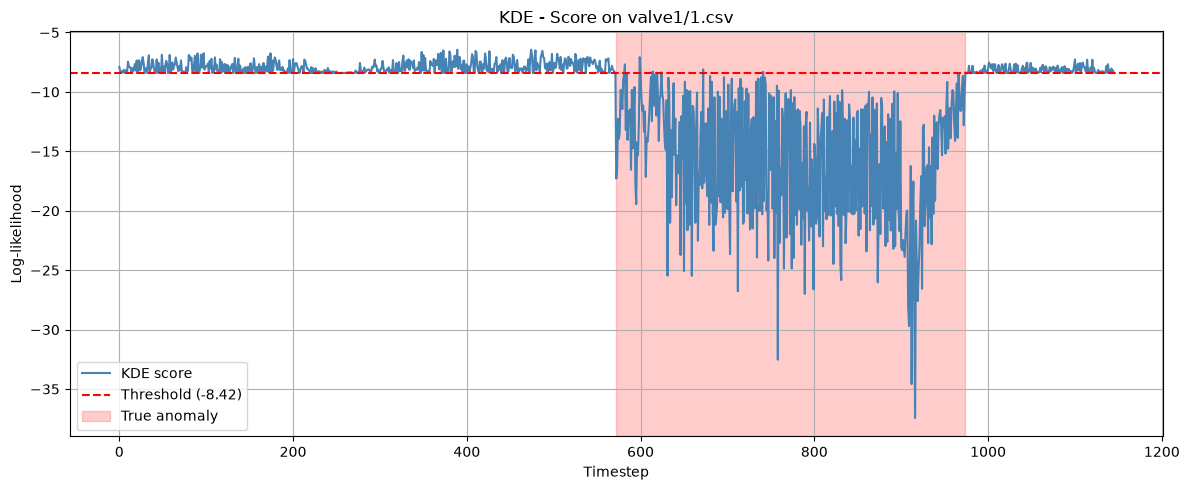

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import os
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

with open("preprocessing.pkl", "rb") as f:
    prep = pickle.load(f)

features = prep["features"]
all_files = prep["all_files"]

def train_and_evaluate_kde(fpath, features, bw=0.5):
    df = pd.read_csv(fpath, sep=";")
    df_normal = df[df["anomaly"] == 0]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_normal[features].values)

    kde = KernelDensity(kernel="gaussian", bandwidth=bw)
    kde.fit(X_train)

    scores_train = kde.score_samples(X_train)
    threshold = np.percentile(scores_train, 5)

    X_all = scaler.transform(df[features].values)
    scores_all = kde.score_samples(X_all)

    first_real = df[df["anomaly"] == 1].index[0]
    detections = np.where(scores_all < threshold)[0]
    detections_after = detections[detections >= first_real]

    if len(detections_after) > 0:
        first_detected = detections_after[0]
        delay = first_detected - first_real
    else:
        first_detected = None
        delay = None

    return {
        "first_real": first_real,
        "first_detected": first_detected,
        "delay": delay,
        "scores": scores_all,
        "threshold": threshold,
        "df": df
    }

# Visualisation on valve1/1.csv
result = train_and_evaluate_kde(all_files[1], features)

plt.figure(figsize=(12, 5))
plt.plot(result["scores"], color="steelblue", label="KDE score")
plt.axhline(y=result["threshold"], color="red", linestyle="--",
            label=f"Threshold ({result['threshold']:.2f})")
anomaly_idx = result["df"][result["df"]["anomaly"] == 1].index
plt.axvspan(anomaly_idx[0], anomaly_idx[-1], alpha=0.2, color="red", label="True anomaly")
plt.xlabel("Timestep")
plt.ylabel("Log-likelihood")
plt.title("KDE - Score on valve1/1.csv")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Results on all files

In [2]:
results_kde = []

for fpath in all_files:
    res = train_and_evaluate_kde(fpath, features)
    folder = fpath.split("/")[-2]
    fname = fpath.split("/")[-1]
    results_kde.append({
        "file": f"{folder}/{fname}",
        "folder": folder,
        "first_real": res["first_real"],
        "first_detected": res["first_detected"],
        "delay": res["delay"]
    })

df_results_kde = pd.DataFrame(results_kde)
print(df_results_kde[["file", "delay"]])
print(f"Mean delay: {df_results_kde['delay'].mean():.1f} timesteps")
print(f"Not detected: {df_results_kde['delay'].isna().sum()}")

# Files where detection failed
failed = df_results_kde[df_results_kde["delay"].isna()]
if len(failed) > 0:
    print("Failed detections:")
    print(failed[["file"]])
else:
    print("All anomalies detected successfully.")

             file  delay
0    valve1/0.csv      0
1    valve1/1.csv      0
2   valve1/10.csv      0
3   valve1/11.csv      0
4   valve1/12.csv      0
5   valve1/13.csv      0
6   valve1/14.csv      0
7   valve1/15.csv      0
8    valve1/2.csv      0
9    valve1/3.csv      0
10   valve1/4.csv      0
11   valve1/5.csv      0
12   valve1/6.csv      0
13   valve1/7.csv      0
14   valve1/8.csv      0
15   valve1/9.csv      0
16   valve2/0.csv      0
17   valve2/1.csv      0
18   valve2/2.csv      0
19   valve2/3.csv      0
20    other/1.csv      0
21   other/10.csv      0
22   other/11.csv      1
23   other/12.csv      0
24   other/13.csv      1
25   other/14.csv     15
26    other/2.csv      0
27    other/3.csv      0
28    other/4.csv      0
29    other/5.csv      0
30    other/6.csv      0
31    other/7.csv      0
32    other/8.csv      1
33    other/9.csv      0
Mean delay: 0.5 timesteps
Not detected: 0
All anomalies detected successfully.


## Cases with detection delay

The three files where KDE did not detect the anomaly immediately. The left plot shows the full sequence; the right plot zooms in on the transition zone to highlight the gap between the true anomaly start (green) and the first alarm raised by the model (orange).

Files with delay > 0: 4


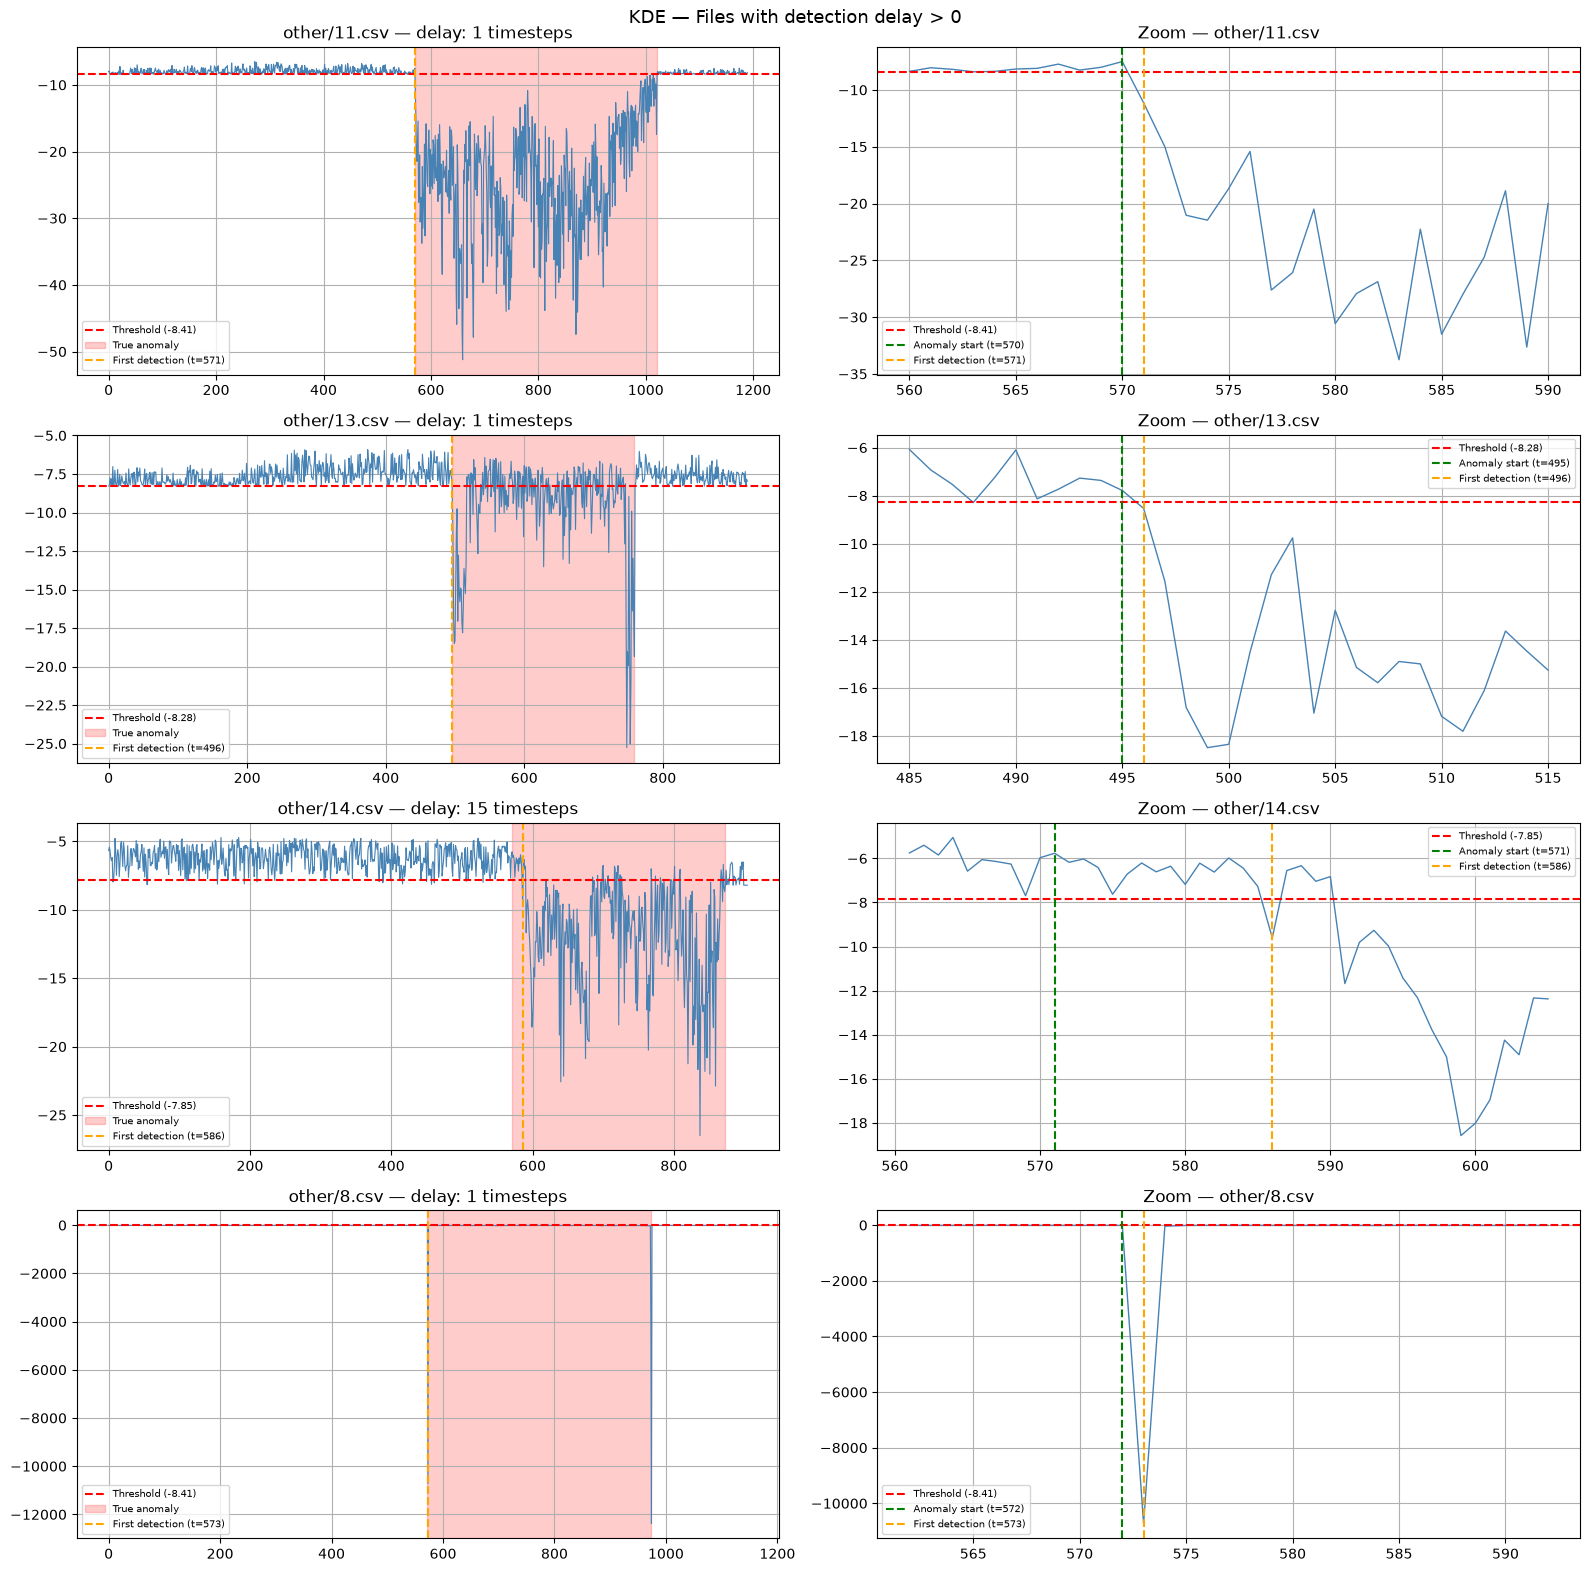

In [3]:
# Plot dei 3 casi con ritardo > 0
delayed = df_results_kde[df_results_kde["delay"] > 0]
print(f"Files with delay > 0: {len(delayed)}")

fig, axes = plt.subplots(len(delayed), 2, figsize=(16, 4 * len(delayed)))

for i, (_, row) in enumerate(delayed.iterrows()):
    fpath = [f for f in all_files if row["file"] in f][0]
    res = train_and_evaluate_kde(fpath, features)
    scores = res["scores"]
    threshold = res["threshold"]
    df = res["df"]
    anomaly_idx = df[df["anomaly"] == 1].index
    first_real = res["first_real"]
    first_detected = res["first_detected"]

    # Plot completo
    axes[i, 0].plot(scores, color="steelblue", linewidth=0.8)
    axes[i, 0].axhline(y=threshold, color="red", linestyle="--", label=f"Threshold ({threshold:.2f})")
    axes[i, 0].axvspan(anomaly_idx[0], anomaly_idx[-1], alpha=0.2, color="red", label="True anomaly")
    axes[i, 0].axvline(x=first_detected, color="orange", linestyle="--", label=f"First detection (t={first_detected})")
    axes[i, 0].set_title(f"{row['file']} — delay: {row['delay']} timesteps")
    axes[i, 0].legend(fontsize=7)
    axes[i, 0].grid(True)

    # Zoom sulla zona di ritardo
    zoom_start = max(0, first_real - 10)
    zoom_end = min(len(scores), first_detected + 20)
    axes[i, 1].plot(range(zoom_start, zoom_end), scores[zoom_start:zoom_end], color="steelblue", linewidth=1)
    axes[i, 1].axhline(y=threshold, color="red", linestyle="--", label=f"Threshold ({threshold:.2f})")
    axes[i, 1].axvline(x=first_real, color="green", linestyle="--", label=f"Anomaly start (t={first_real})")
    axes[i, 1].axvline(x=first_detected, color="orange", linestyle="--", label=f"First detection (t={first_detected})")
    axes[i, 1].set_title(f"Zoom — {row['file']}")
    axes[i, 1].legend(fontsize=7)
    axes[i, 1].grid(True)

plt.suptitle("KDE — Files with detection delay > 0", fontsize=13)
plt.tight_layout()
plt.show()

## Detection delay visualisation

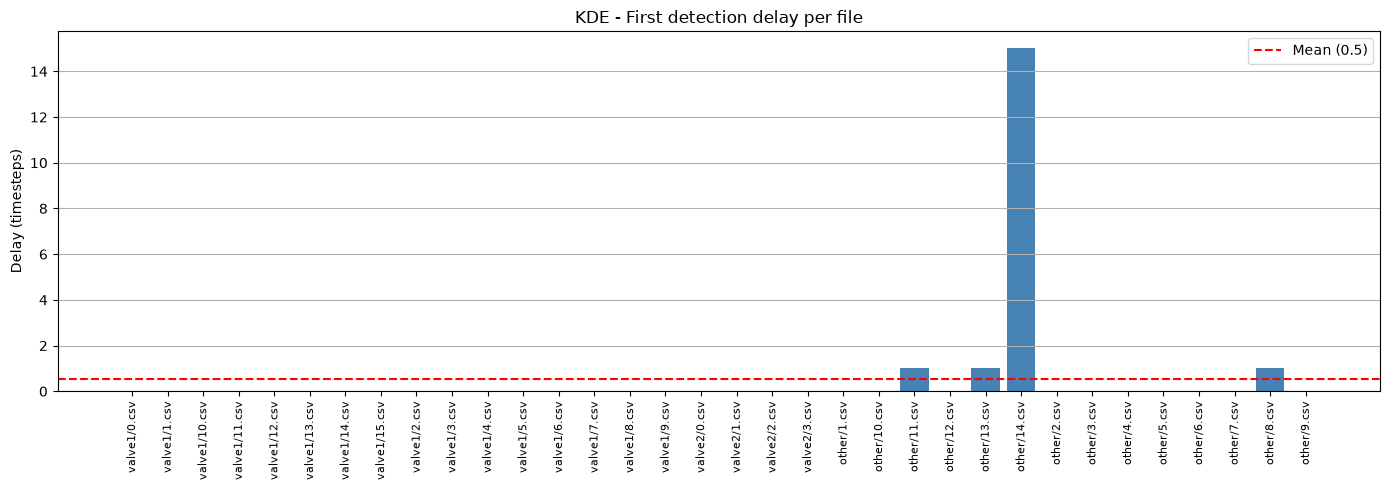

In [4]:
plt.figure(figsize=(14, 5))
plt.bar(df_results_kde["file"], df_results_kde["delay"], color="steelblue")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Delay (timesteps)")
plt.title("KDE - First detection delay per file")
plt.axhline(y=df_results_kde["delay"].mean(), color="red", linestyle="--",
            label=f"Mean ({df_results_kde['delay'].mean():.1f})")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()